In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Check data
print(df.head())
print(df.info())
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes

C:\Users\hajer\AppData\Local\Temp\ipykernel_2116\2383150792.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sepal_length = df.groupby('species')['sepal length (cm)'].mean()


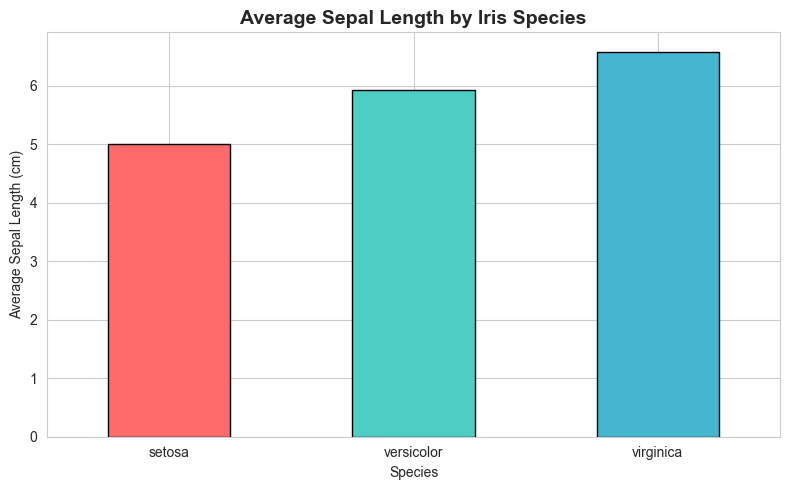

In [2]:
# Bar chart: Average Sepal Length per Species
avg_sepal_length = df.groupby('species')['sepal length (cm)'].mean()

plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
avg_sepal_length.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Sepal Length by Iris Species', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Average Sepal Length (cm)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

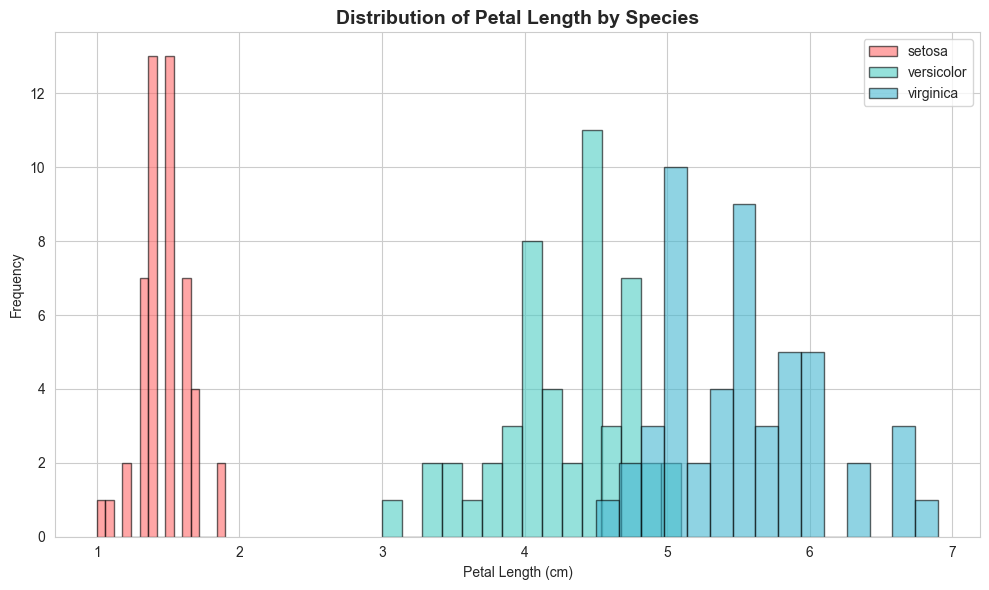

In [3]:
# Histogram: Distribution of Petal Length
plt.figure(figsize=(10, 6))
for species, color in zip(df['species'].unique(), ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    subset = df[df['species'] == species]
    plt.hist(subset['petal length (cm)'], bins=15, alpha=0.6, label=species, color=color, edgecolor='black')

plt.title('Distribution of Petal Length by Species', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

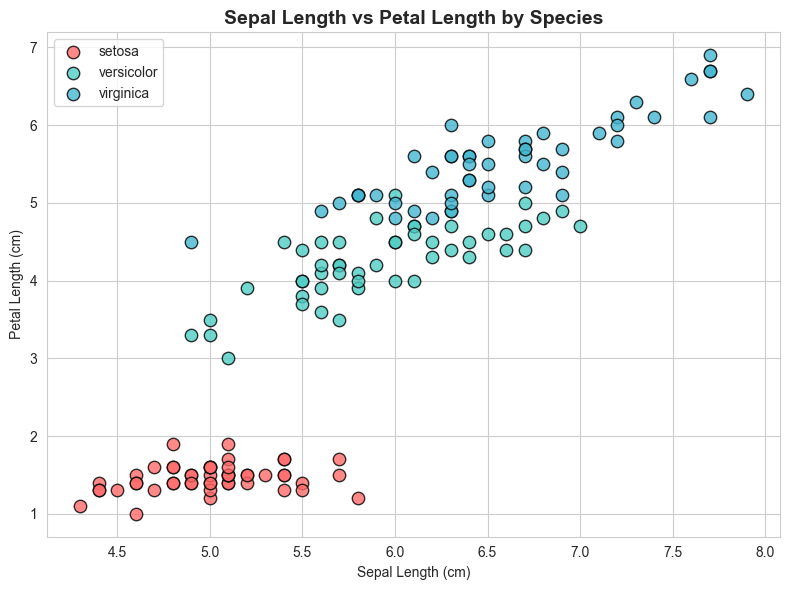

In [4]:
# Scatter plot: Sepal Length vs Petal Length
plt.figure(figsize=(8, 6))
species_colors = {'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1'}

for species, color in species_colors.items():
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal length (cm)'], subset['petal length (cm)'], 
                c=color, label=species, s=80, edgecolor='black', alpha=0.8)

plt.title('Sepal Length vs Petal Length by Species', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.tight_layout()
plt.show()

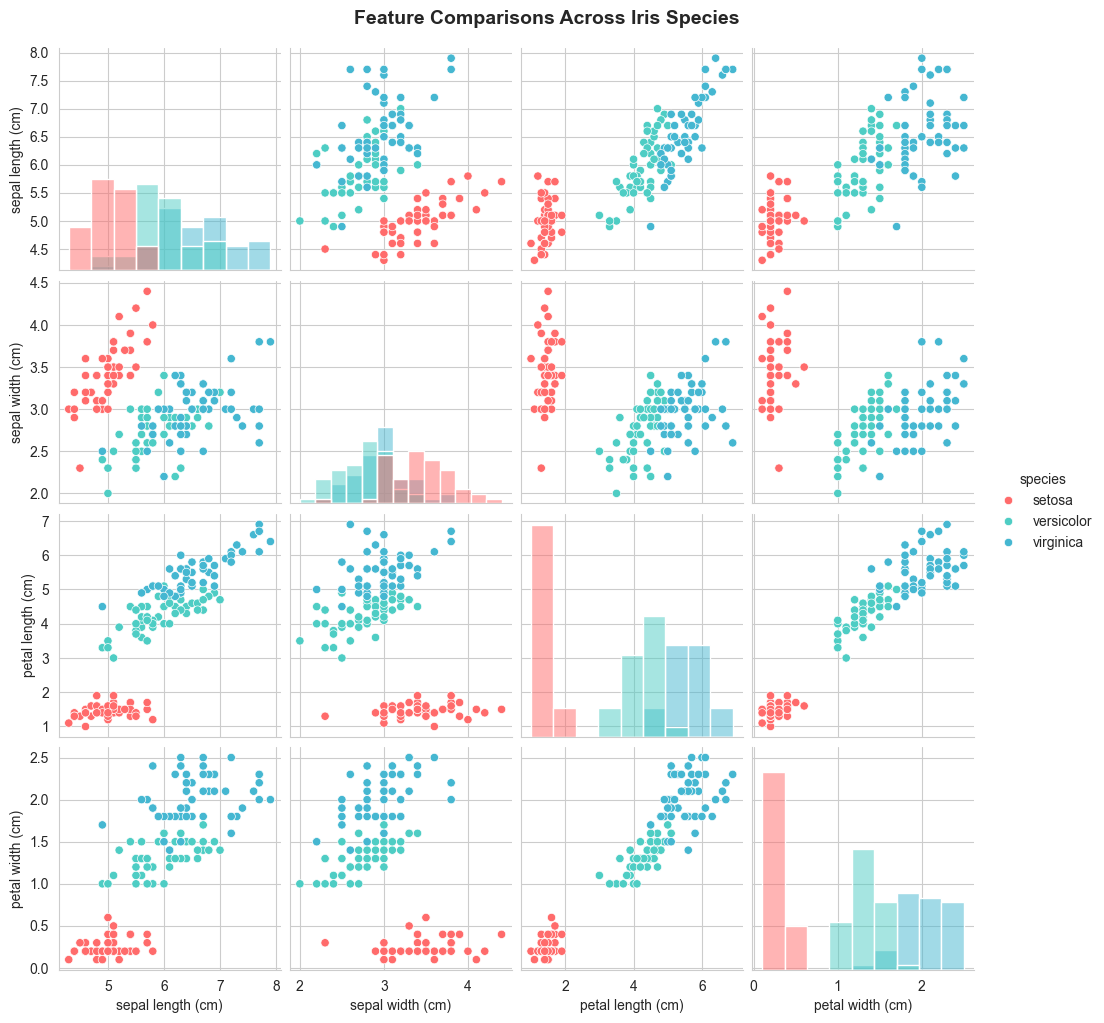

In [5]:
# Feature comparison: Pairplot (FIXED)
pairplot = sns.pairplot(df, hue='species', 
                        palette={'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1'},
                        diag_kind='hist',
                        height=2.5)

# Ajouter le titre
pairplot.fig.suptitle('Feature Comparisons Across Iris Species', 
                       y=1.02, fontsize=14, fontweight='bold')

# Afficher
plt.show()

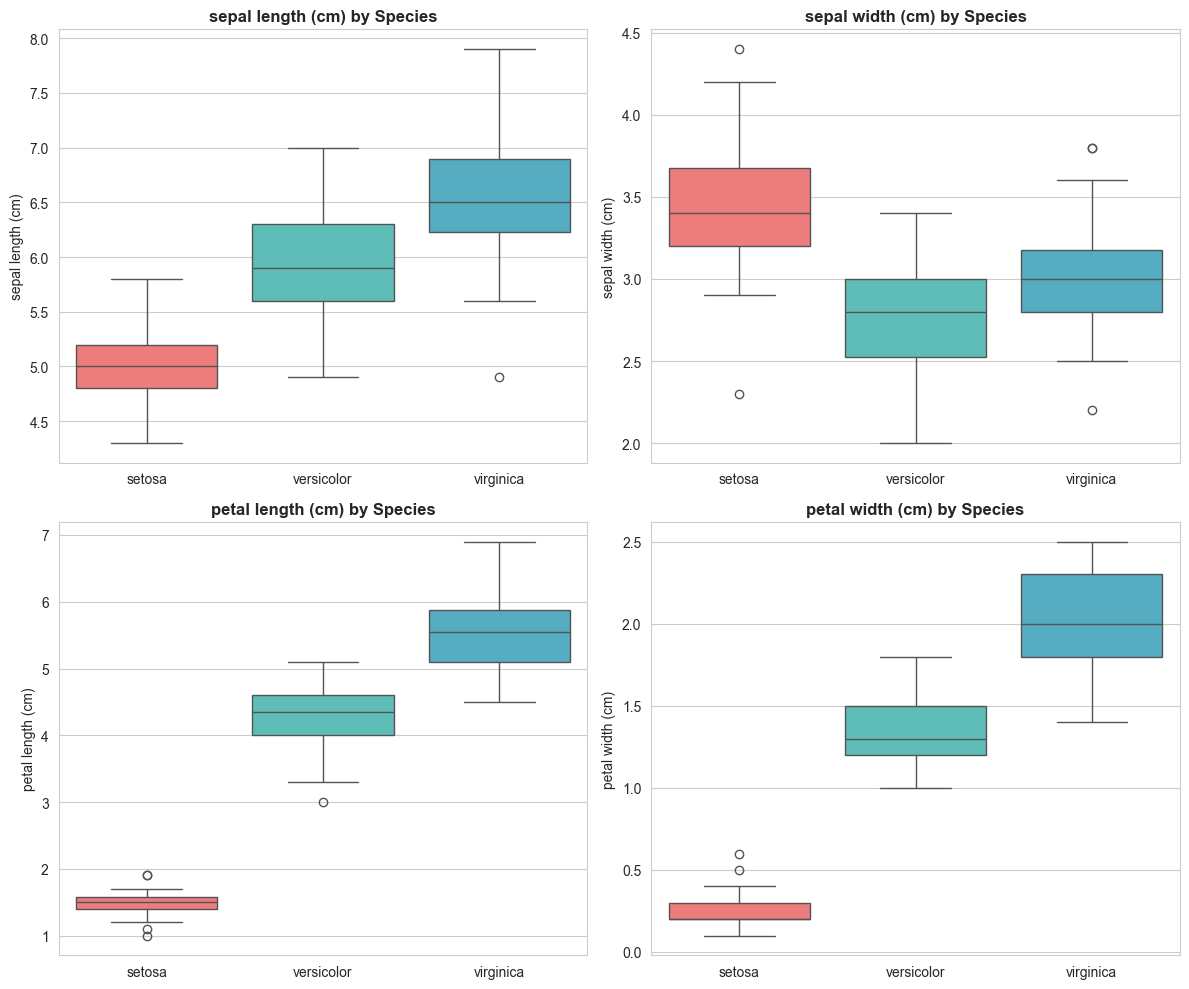

In [6]:
# Boxplot: All features by species 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = df.columns[:-1]
colors = {'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1'}

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feature, data=df, ax=ax, 
                hue='species', palette=colors, legend=False)
    ax.set_title(f'{feature} by Species', fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

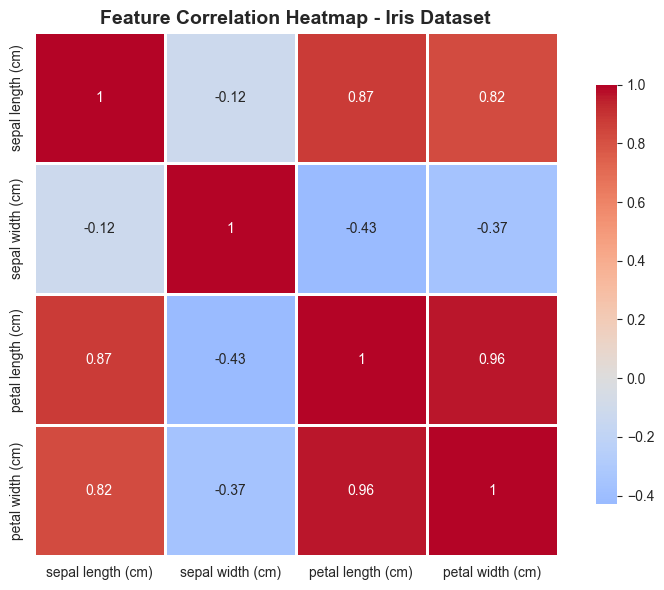

In [7]:
# Correlation heatmap
corr_matrix = df.drop('species', axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap - Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()